# Brain Tumor Detection

### Loading Data

In [1]:
# Renaming images
# Example: from gg (127).jpg to gg__127_.jpg

import os
import re

def clean_filenames(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            old_path = os.path.join(root, filename)
            # Replace spaces and parentheses
            new_filename = re.sub(r"[ ()]", "_", filename)
            new_path = os.path.join(root, new_filename)
            if old_path != new_path:
                os.rename(old_path, new_path)

# Run it on your training dataset
# My data is one folder above the git project
clean_filenames("../data/archive/training")

#### Following code uses ImageDataGenerator, which doesn't support advanced data augmentation that we need, so we should switch to using tf.data.Dataset and preprocess_input from tensorflow.keras.applications.vgg16

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

training_path = "../data/archive/training"


# Use the VGG16-specific preprocessing function
"""Applies VGG16 preprocessing to every image:
- Converts RGB → BGR
- Subtracts ImageNet mean (centering)
- Splits the dataset into: 80% training and 20% validation
- Note: This does not augment images (no flip, noise, etc.)"""

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # THIS is important
    validation_split=0.2  # Create validation split from training set
)



""" Loads training images:
- Resizes each to 224×224 (required by VGG16)
- Returns batches of size 32
- One-hot encodes labels (4 classes → [1, 0, 0, 0])
- Only uses the 80% “training” part of the data or 20% for validation below """

train_generator = train_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),      # Resize to VGG16 input
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.


In [3]:
# Checking if the classes have been recognized

print("Class indices:", train_generator.class_indices)

Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..74.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..74.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..70.5305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-53.84..76.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..72.5305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..76.0305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-61.34..73.5305].
Clipping input data to the 

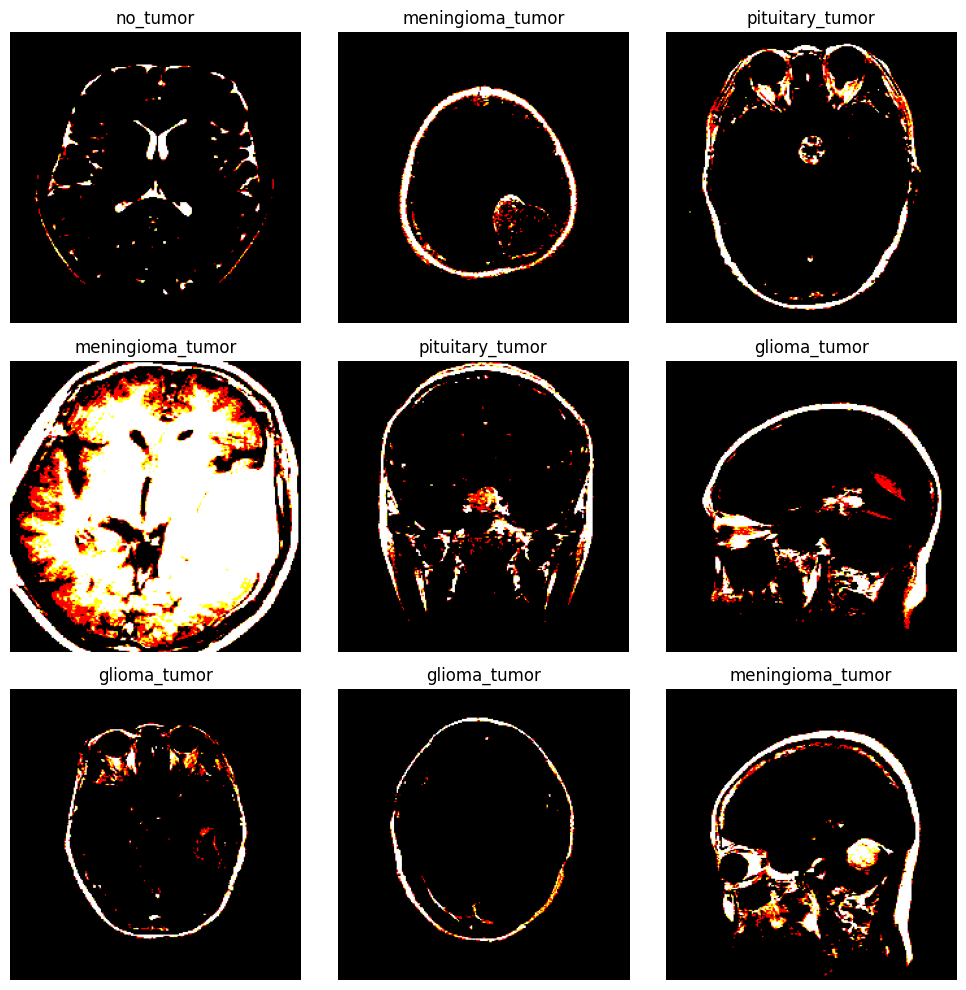

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of data
images, labels = next(train_generator)

# Get class names from generator
class_names = list(train_generator.class_indices.keys())

# Plot 9 sample images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] + 1) / 2)  # un-preprocess VGG input (optional)
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()


# Images look different than the original ones because this is already preprocessed for CNN 




Found 2297 images belonging to 4 classes.


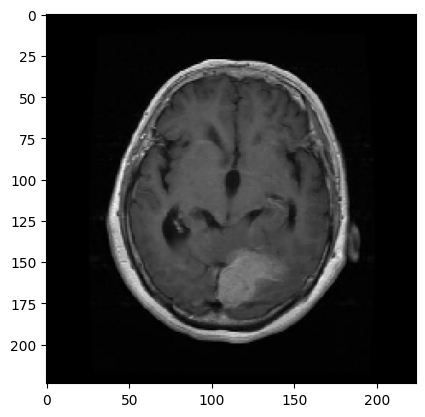

In [10]:
preview_datagen = ImageDataGenerator(validation_split=0.2)

preview_generator = preview_datagen.flow_from_directory(
    '../data/archive/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

images, labels = next(preview_generator)

plt.imshow(images[0] / 255.0) 

# How the original data looks like

#### tf.data.Dataset

Loading data and splitting into train (80%) and validation (20%) data sets


In [38]:
# resizing to VGG image size (224x224)
# uses seed=42 to shuffle the file list deterministically (making the split reproducible)
# returns batches of 32 images

train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/archive/training",
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/archive/training",
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=42  # important to keep same seed to ensure same split
)

class_names = train_ds.class_names

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.


**Augmentation**

Apply random combination of augmentations during training. Each image in the training dataset gets different random augmentations applied on-the-fly during training.

? Do apply multiple augmentations randomly together on each image during training. It’s better for generalization and standard practice.

In [39]:
def augment(image, label):
    # Random horizontal flip with 50% chance
    image = tf.image.random_flip_left_right(image)
    
    # Random brightness adjustment
    image = tf.image.random_brightness(image, max_delta=0.1)
    
    # Random contrast adjustment
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    # Add Gaussian noise
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=10.0)
    image = tf.cast(image, tf.float32) + noise
    image = tf.clip_by_value(image, 0.0, 255.0)
    
    return image, label

**Preprocessing** normalizes image pixel values to the format VGG16 expects: Converts from RGB uint8 [0..255] range to float with mean subtraction and scaling. This helps the model work better because it matches the original training data distribution.

**Preprocessing after augmentation:**
- Recommended way
- Apply augmentations on the original image in a standard pixel range [0, 255] or normalized [0,1]
- After all augmentations, call preprocess_input once just before feeding the batch to the model
- This keeps augmentation stable and consistent.

In [40]:
def preprocess(image, label):
    image = preprocess_input(image)  # now do VGG16 preprocessing
    return image, label

**Augmenting on-the-fly**

- We should augment the entire training set, but not by duplicating it or permanently altering it.
- On-the-fly doesn’t change the original data.
- Each image is augmented randomly and differently every epoch.
- We don’t need to store extra copies or divide your training set manually.

DONT'S:
- applying augmentation to only 50% of the dataset to “preserve clean examples.” That just weakens the generalization.
- manually augmenting images and saving them (unless we absolutely need static files for older tools).

In [41]:
train_ds = (
    train_ds
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE) # augmenting
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) # preprocessing
    .prefetch(tf.data.AUTOTUNE)  # prepare the next batch of data while the current one is being used by the model
)

### Building VGG16-based CNN model

- VGG16 base as a feature extractor
- Classification head for our 4 classes

In [42]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Load VGG16 without the top layer (no classification head)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model for now

# Create your model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')  # 4 classes: glioma, meningioma, pituitary, no tumor
])

In [43]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.4246 - loss: 110.4347 - val_accuracy: 0.7178 - val_loss: 33.5720
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.6536 - loss: 77.9390 - val_accuracy: 0.7213 - val_loss: 39.0179
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.7263 - loss: 56.0495 - val_accuracy: 0.7718 - val_loss: 30.8228
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.7702 - loss: 40.9269 - val_accuracy: 0.7561 - val_loss: 36.4329
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.8085 - loss: 33.8192 - val_accuracy: 0.7160 - val_loss: 45.1842
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.8482 - loss: 24.8008 - val_accuracy: 0.7509 - val_loss: 43.9803
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.8473 - loss: 25.3334 - val_accuracy: 0.6812 - val_loss: 65.5848
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.8653 - loss: 18

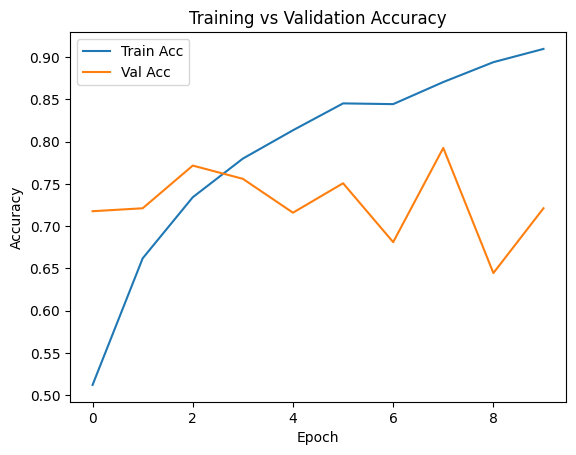

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


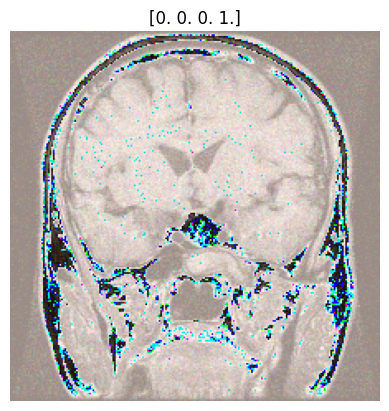

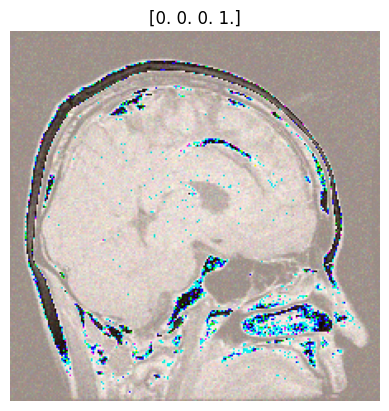

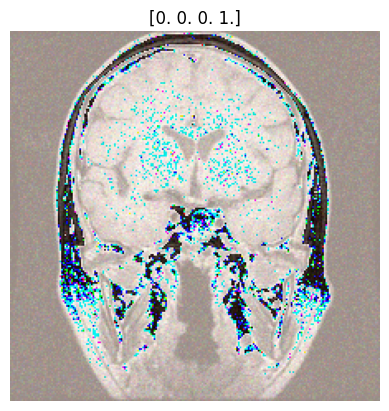

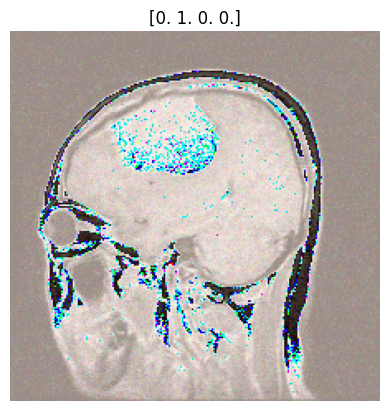

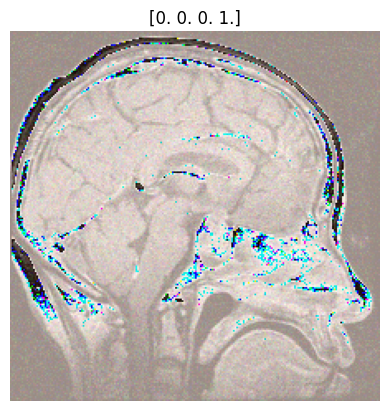

2025-05-29 10:56:17.214640: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [46]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(5):
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(str(labels[i].numpy()))
        plt.axis("off")
        plt.show()

In [57]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
from PIL import Image

# Load image and resize
img_path = "../data/archive/testing/no_tumor/image.jpg"  # your test image
img = Image.open(img_path).resize((224, 224))
img = np.array(img)

# If grayscale, convert to RGB
if img.ndim == 2:
    img = np.stack([img]*3, axis=-1)

# Expand dims and preprocess
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)

In [58]:
pred = model.predict(img)
pred_class = np.argmax(pred, axis=1)
print("Predicted class:", class_names[pred_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted class: meningioma_tumor
